<a href="https://colab.research.google.com/github/ismaelpereziimas/Procesamiento-de-Imagenes-Medicas/blob/main/Notebooks/2026_Procesamiento_de_Imagenes_Medicas_Clasificaci%C3%B3n_Imagenes_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Procesamiento de imágenes médicas**
----------
# Clasificación de imágenes del dataset CIFAR-10
-------

Por: Ing. Ismael Pérez/Ing. Gabriel Carcedo.

Este código fue diseñado originalmente para la Escuela de Invierno en Ciencia de Datos 2026.

CIFAR-10 es un conjunto de datos clásico de visión por computadora que contiene 60 000 imágenes a color de tamaño 32×32 píxeles, distribuidas en 10 clases de objetos cotidianos (aviones, autos, animales, etc.).
Se divide en 50 000 imágenes de entrenamiento y 10 000 de prueba, y es ampliamente utilizado para enseñar y evaluar redes neuronales convolucionales (CNNs).


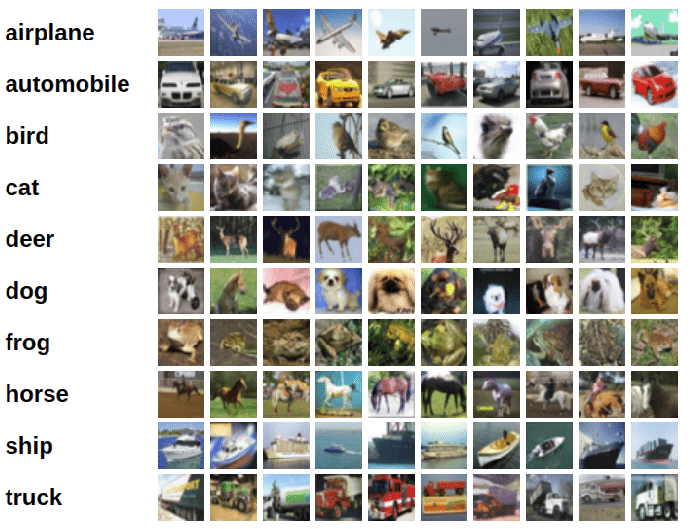






# Importación de las librerías y el dataset

En este paso importaremos las librerías necesarias

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

import seaborn as sns

In [2]:
cifar10=keras.datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
class_names = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado','Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Análisis exploratorio de los datos
En esta etapa se visualizan los datos de diferentes formas para ver las relaciones que tienen entre sí, así como diferentes métricas.

En esta ocasión, solo se mostrará la tabla con los valores obtenidos y posteriormente se graficará la distribución de los por característica y clase. También se graficará la clasificación por cada par de características.

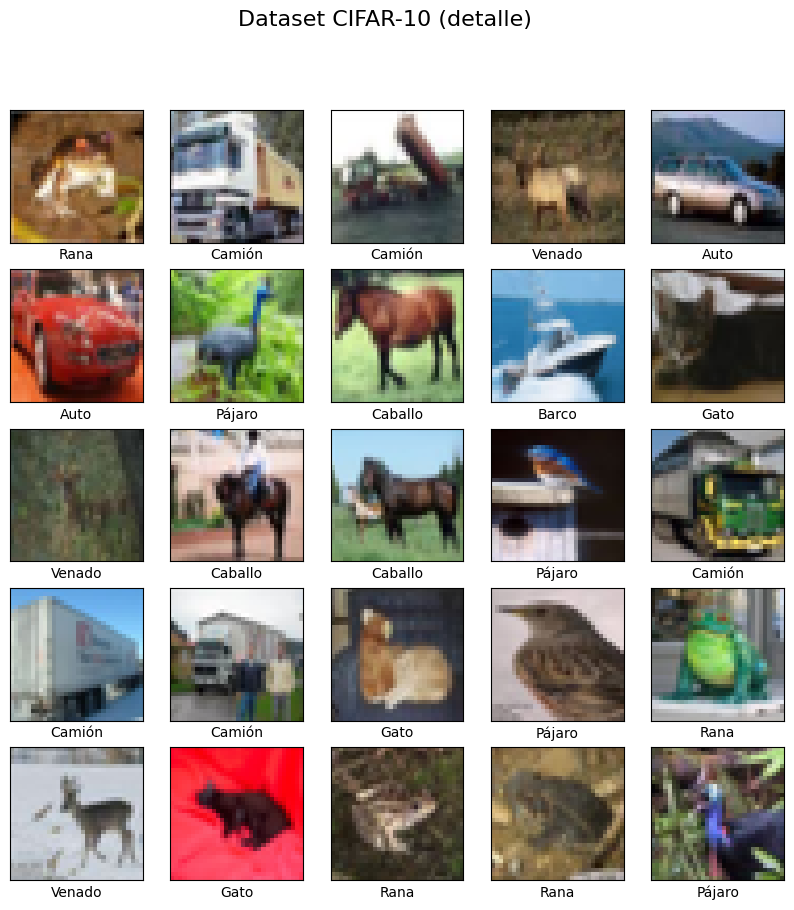

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.suptitle("Dataset CIFAR-10 (detalle)", fontsize=16)
plt.show()

In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [32]:
test_labels_categorical=to_categorical(test_labels,10)
train_labels_categorical=to_categorical(train_labels,10)

In [33]:
inputs = keras.Input(shape=(32, 32, 3)) #la entrada es una imagen de 32x32, al ser RGB, la imagen tiene 3 matrices.

x = layers.Conv2D(32, (3,3), activation='relu', name='conv_1')(inputs)
x = layers.MaxPooling2D((2,2), name='pool_1')(x)

x = layers.Conv2D(64, (3,3), activation='relu', name='conv_2')(x)
x = layers.MaxPooling2D((2,2), name='pool_2')(x)

x = layers.Conv2D(64, (3,3), activation='relu', name='conv_3')(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history= model.fit(
    train_images,
    train_labels_categorical,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 100ms/step - accuracy: 0.4106 - loss: 1.6185 - val_accuracy: 0.4970 - val_loss: 1.4122
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 91ms/step - accuracy: 0.5584 - loss: 1.2432 - val_accuracy: 0.6082 - val_loss: 1.1234
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.6164 - loss: 1.0848 - val_accuracy: 0.6204 - val_loss: 1.0736
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6534 - loss: 0.9923 - val_accuracy: 0.6592 - val_loss: 0.9879
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.6795 - loss: 0.9156 - val_accuracy: 0.6716 - val_loss: 0.9412


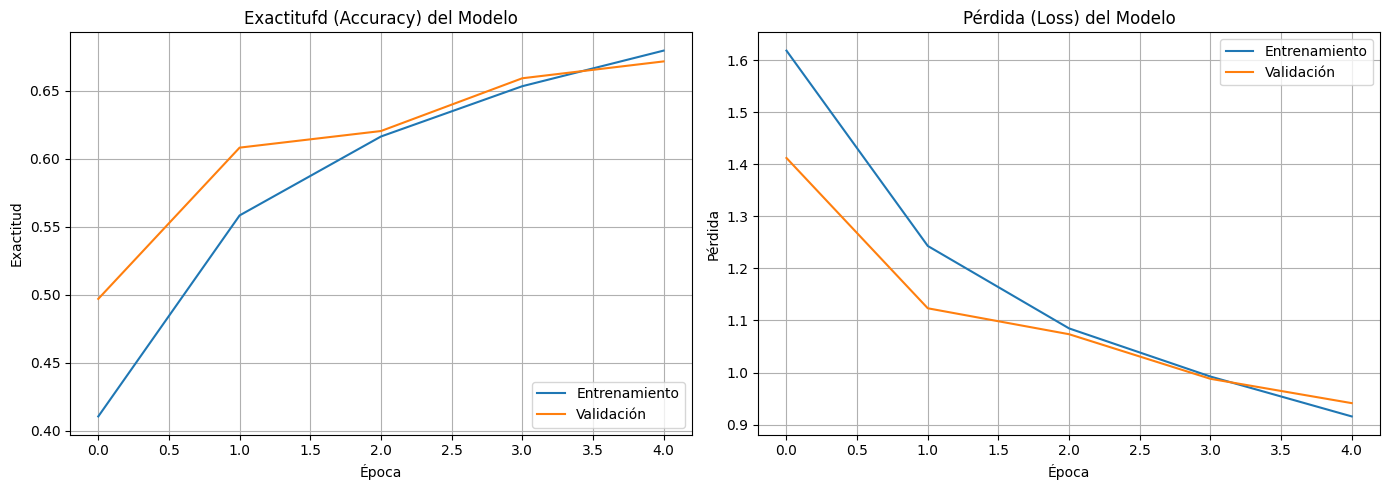

In [35]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Exactitufd (Accuracy) del Modelo')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss) del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
print(test_labels_categorical)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [46]:
clasificaciones=model.predict(test_images)
print(clasificaciones)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
[[1.1895384e-03 1.1570967e-03 1.5684703e-02 ... 8.0307975e-04
  6.5394990e-02 5.4090220e-04]
 [6.3998111e-02 3.6442686e-02 1.7636309e-04 ... 5.1228176e-06
  8.9586312e-01 3.1766328e-03]
 [5.9445716e-02 3.2299468e-01 1.6269177e-03 ... 1.4763048e-04
  5.7219005e-01 3.9049640e-02]
 ...
 [1.8818371e-04 5.0438266e-05 4.8179556e-02 ... 2.3743384e-02
  6.7287692e-05 5.3706724e-04]
 [1.3378689e-01 2.4368778e-01 1.5049717e-02 ... 5.4879863e-02
  4.6977634e-03 5.5733132e-03]
 [1.2789824e-05 2.8455379e-05 4.9561675e-04 ... 9.4827121e-01
  2.0162772e-06 1.4420648e-05]]


In [47]:
clases_predichas=np.argmax(clasificaciones,axis=1)
print(clases_predichas)

[3 8 8 ... 5 4 7]


In [48]:
clases_reales=np.argmax(test_labels_categorical,axis=1)
print(clases_reales)

[3 8 8 ... 5 1 7]


In [49]:
matriz=confusion_matrix(clases_reales,clases_predichas)
print(matriz)

[[653  21  71  40  10   5  14   8 162  16]
 [ 33 784   7  26   3   4  17   1  69  56]
 [ 53   9 528 170  65  48  70  23  31   3]
 [ 15  11  64 702  40  57  71  15  17   8]
 [ 22   3  89 169 514  23  83  66  27   4]
 [ 12   4  50 427  24 407  35  27  11   3]
 [  4   3  43 107  13   7 809   3   8   3]
 [ 16   2  37 166  61  46  13 640   5  14]
 [ 40  30   9  24   3   3   6   3 866  16]
 [ 39 151   8  56   3   8  17  15  72 631]]


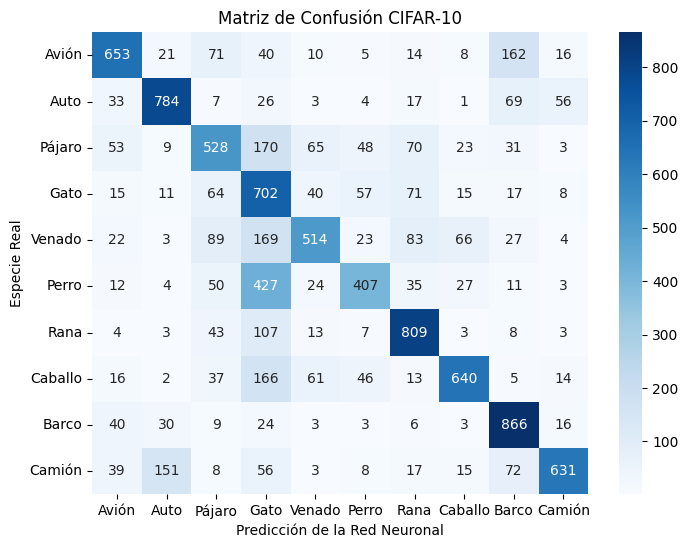

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado','Perro', 'Rana', 'Caballo', 'Barco', 'Camión'],
            yticklabels=['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado','Perro', 'Rana', 'Caballo', 'Barco', 'Camión'])
plt.title('Matriz de Confusión CIFAR-10')
plt.xlabel('Predicción de la Red Neuronal')
plt.ylabel('Especie Real')
plt.show()

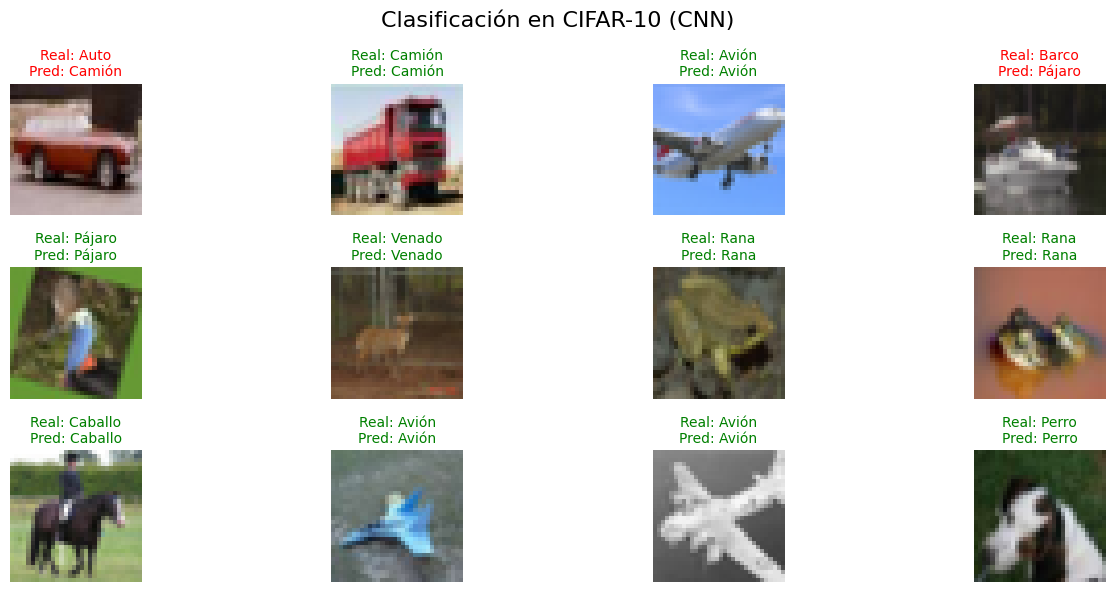

In [63]:

num_images = 12
indices = np.random.choice(len(test_images), num_images, replace=False)

plt.figure(figsize=(14, 6))

for i, idx in enumerate(indices):
    img = test_images[idx]
    true_label = test_labels[idx][0]

    pred = model.predict(img[np.newaxis, ...], verbose=0)
    pred_label = np.argmax(pred)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')

    color = 'green' if pred_label == true_label else 'red'
    plt.title(
        f"Real: {class_names[true_label]}\n"
        f"Pred: {class_names[pred_label]}",
        color=color,
        fontsize=10
    )

plt.suptitle("Clasificación en CIFAR-10 (CNN)", fontsize=16)
plt.tight_layout()
plt.show()

In [64]:

conv_layers = [
    layer for layer in model.layers
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D))
]

activation_model = keras.Model(
    inputs=model.input,
    outputs=[layer.output for layer in conv_layers]
)


In [65]:
activations = activation_model.predict(img[np.newaxis, ...])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


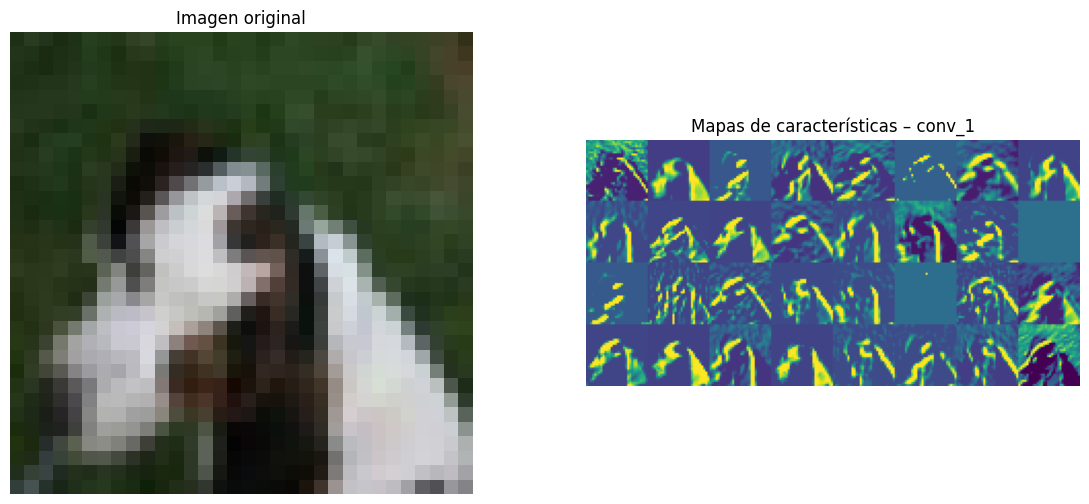

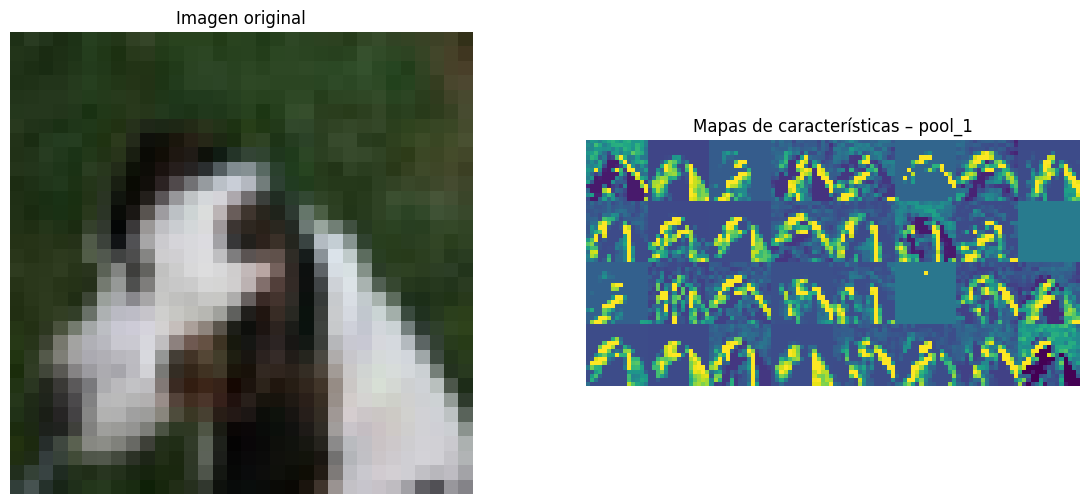

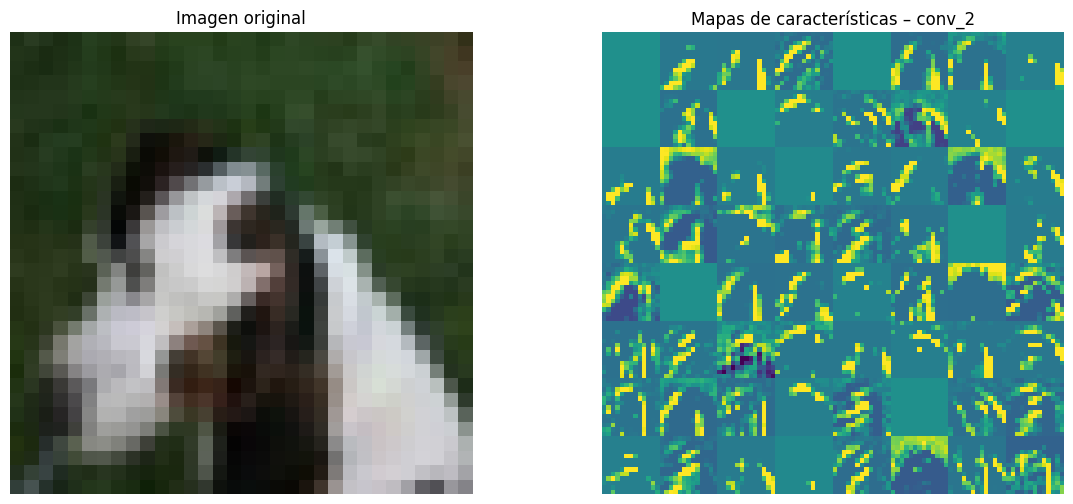

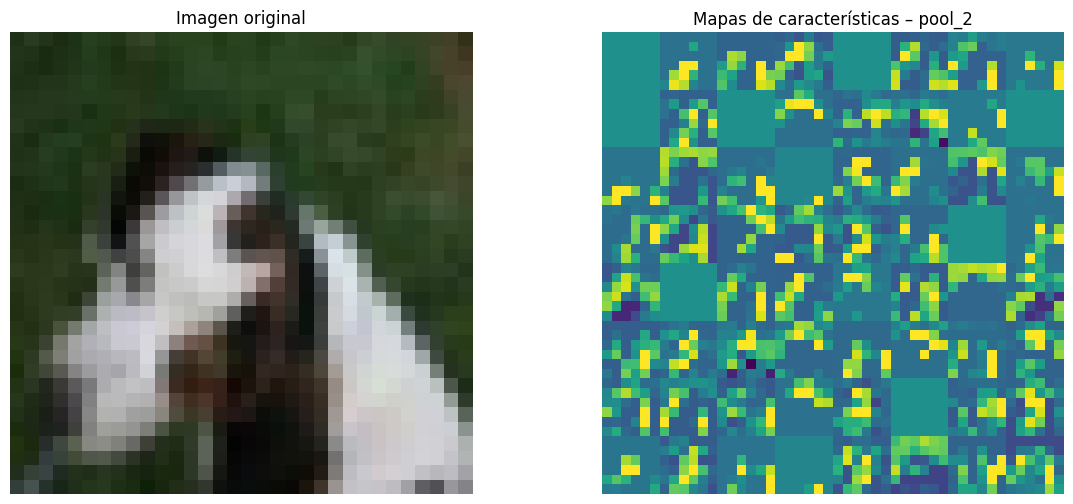

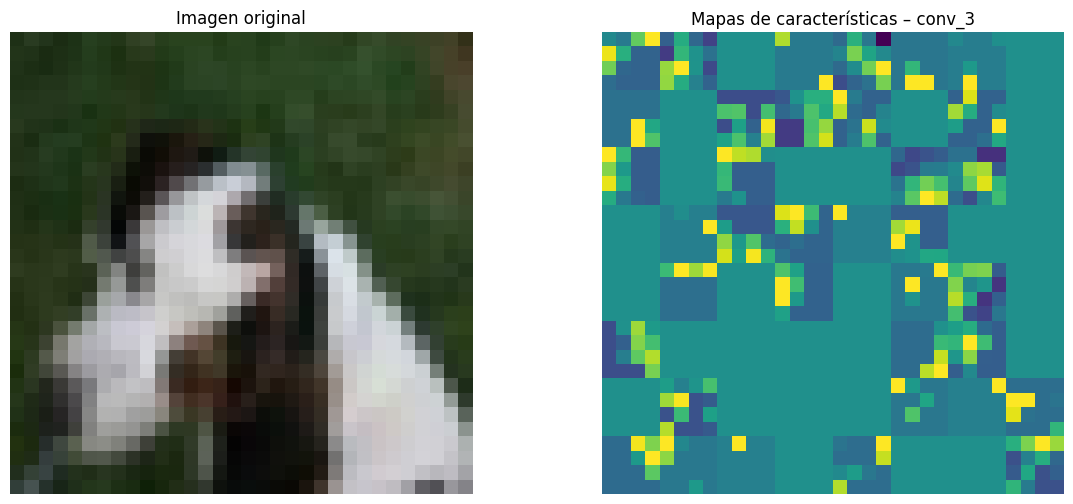

In [66]:
for layer, activation in zip(conv_layers, activations):

    n_features = activation.shape[-1]
    size = activation.shape[1]

    n_cols = n_features // 8
    display_grid = np.zeros((size * n_cols, 8 * size))

    for col in range(n_cols):
        for row in range(8):
            channel = activation[0, :, :, col * 8 + row]
            channel -= channel.mean()
            channel /= (channel.std() + 1e-5)
            channel = channel * 64 + 128
            channel = np.clip(channel, 0, 255)

            display_grid[
                col * size : (col + 1) * size,
                row * size : (row + 1) * size
            ] = channel

    plt.figure(figsize=(14, 6))

    # Imagen original
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Imagen original")
    plt.axis('off')

    # Mapas de características
    plt.subplot(1, 2, 2)
    plt.imshow(display_grid, cmap='viridis')
    plt.title(f"Mapas de características – {layer.name}")
    plt.axis('off')

    plt.show()